# 01 — Order books and live capture, from the bytes up

This notebook is the walkthrough for `data_engine/book.py` and
`data_engine/capture.py`. By the end you should be able to answer, without
notes: what an order book is, why an exchange sends you *diffs* instead of
the book, how to turn those diffs back into a book without silently
corrupting it, and how you would prove to a skeptic that your book is right.

We work from a real archive slice — `notebooks/sample_data/btcusdt_sample.jsonl.gz`,
8,002 records of live Binance BTCUSDT depth and trades captured by
`data_engine.capture` — and rebuild the book from it, event by event.

**Roadmap**

1. What a limit order book is.
2. What is actually on the tape.
3. Why prices are integers here and never floats.
4. The snapshot-sync algorithm, step by step.
5. Replaying 868 diffs into a live book.
6. Looking at it: the ladder, and the mid over time.
7. Breaking it on purpose: a sequence gap.
8. Proving it: an offline cross-check against the exchange's own snapshot.

## 1. What a limit order book is

An order book is the exchange's list of resting intentions. Buyers post
**bids** (I will buy X at this price or lower); sellers post **asks** (I will
sell X at this price or higher). The exchange sorts each side by price and
matches whatever crosses.

```
        BIDS (buyers)                 ASKS (sellers)
        price      qty                price      qty
     64,696.28    0.412            64,696.30    1.204
     64,696.27    1.883            64,696.31    0.077
     64,696.26    0.054            64,696.32    2.910
     64,696.25    3.120            64,696.33    0.615
          ^                             ^
     best bid = 64,696.28         best ask = 64,696.30
          |_____________  spread  ____________|
                     mid = 64,696.29
```

Three quantities matter for everything later in this project:

- **best bid / best ask** — the *touch*, the only prices you can trade at right now.
- **spread** — ask minus bid, the round-trip cost of crossing. Stage 5 is
  entirely about whether our signal is bigger than this.
- **mid** — the average of the two. Smooth and symmetric, which makes it a good
  label target, but it is *not a price anyone can trade at*. Remember that.

The book is **strictly ordered**: bids descend, asks ascend, and the best bid
is always below the best ask. If those ever stop being true, our
reconstruction is broken. That is what `OrderBook.assert_valid()` checks.

In [1]:
import gzip
import json
import sys
from collections import Counter
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt

# nbconvert runs with the notebook's directory as cwd; a plain run may not.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data_engine").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from data_engine.book import PRICE_SCALE, QTY_SCALE, OrderBook, SequenceGapError, to_fixed

SAMPLE = REPO_ROOT / "notebooks" / "sample_data" / "btcusdt_sample.jsonl.gz"
with gzip.open(SAMPLE, "rt", encoding="utf-8") as handle:
    records = [json.loads(line) for line in handle]

print(f"{len(records)} records")
print("by source:", dict(Counter(record["source"] for record in records)))

8002 records
by source: {'websocket': 8000, 'rest_depth_sync': 1, 'rest_depth_crosscheck': 1}


### What just came back

Three kinds of record, and the mix tells you how the daemon works:

- **8,000 `websocket` records** — every frame the exchange pushed, stored
  verbatim as a string. Depth diffs and trades, interleaved.
- **1 `rest_depth_sync`** — the REST snapshot the daemon fetched to seed the
  book at startup.
- **1 `rest_depth_crosscheck`** — a snapshot fetched 60 seconds later purely
  to check the book against.

That second and third record are the important design point. A diff stream
describes only *changes*, so an archive of websocket frames alone can never be
replayed into an absolute book — you would have nothing to apply the changes
to. Putting the snapshots on the tape makes the file **self-sufficient**: this
notebook needs no network, and neither will Stage 2's replayer.

## 2. Why the exchange sends diffs, and what one looks like

Pushing the full book on every change would be enormous — BTCUSDT has
thousands of live levels and they change many times a second. So Binance
sends a `depthUpdate`: only the levels that moved, plus a pair of sequence
numbers.

The two sequence numbers are the whole game:

- `U` — first update id covered by this event
- `u` — final update id covered by this event

Consecutive events are contiguous: the next event's `U` is the previous
event's `u + 1`. That contiguity is what lets us *detect* a lost message,
which is the only reason this is a solvable problem at all.

A quantity of `0` means "this level is gone" — deletion and update arrive
through the same field.

In [2]:
first_depth = next(
    json.loads(record["raw"])["data"]
    for record in records
    if record["source"] == "websocket" and json.loads(record["raw"])["data"].get("e") == "depthUpdate"
)

print("event type :", first_depth["e"])
print("symbol     :", first_depth["s"])
print("U (first)  :", first_depth["U"])
print("u (final)  :", first_depth["u"])
print("bid changes:", first_depth["b"][:3], "...")
print("ask changes:", first_depth["a"][:3], "...")

event type : depthUpdate
symbol     : BTCUSDT
U (first)  : 97898281153
u (final)  : 97898281194
bid changes: [['64680.23000000', '3.98595000'], ['64678.00000000', '0.00832000'], ['64675.99000000', '0.28429000']] ...
ask changes: [['64680.24000000', '0.80403000'], ['64680.25000000', '0.00056000'], ['64680.48000000', '0.00018000']] ...


### Reading that event

The event covers a small range of update ids and touches only a handful of
levels. Note the prices and quantities are **decimal strings**, not JSON
numbers — Binance deliberately avoids sending floats, because JSON numbers
would force every consumer through a binary float and lose exactness.

That is a hint about what we should do on our side, which is the next section.

## 3. Why prices are integers here and never floats

The obvious way to store a book is `dict[float, float]`. It is also wrong,
and this is the single most defensible small decision in the module.

Binary floating point cannot represent most decimal ticks exactly. So the
same price level, arriving in two different messages, can land on two
different float keys. The book then grows a duplicate level, and the
`quantity = 0` message that should delete it deletes only one of the two.
The result is a book that is one level too deep at a price that no longer
exists — invisible for hours, and fatal to any feature computed from the
touch.

`data_engine.book` stores everything as **integers on the tick grid**:
`round(real_value * 10^8)`. Exact by construction, exactly comparable, and
it maps straight onto the fixed-width binary format in Stage 2.

In [3]:
for price_string in ["0.29", "0.57", "64696.28"]:
    exact = to_fixed(price_string, PRICE_SCALE)
    via_float = int(float(price_string) * PRICE_SCALE)
    verdict = "same" if exact == via_float else "DIFFERENT  <-- silent corruption"
    print(f"{price_string:>10}  exact={exact:>16,}  via float={via_float:>16,}  {verdict}")

      0.29  exact=      29,000,000  via float=      28,999,999  DIFFERENT  <-- silent corruption
      0.57  exact=      57,000,000  via float=      56,999,999  DIFFERENT  <-- silent corruption
  64696.28  exact=6,469,628,000,000  via float=6,469,628,000,000  same


### There it is

`0.29` and `0.57` do not survive the round trip through a float: multiplying
by 10^8 lands a hair *below* the integer, and truncation loses a tick. Those
are not exotic numbers — they are ordinary prices.

This is why `to_fixed` uses `Decimal` rather than `float`. It is also why
`to_fixed` *raises* when a value has more precision than the 10^8 grid can
hold: quietly truncating would be the same bug in a different coat.

## 4. The synchronisation algorithm

We have a snapshot (a complete book at update id `L`) and a stream of diffs.
Joining them has exactly two failure modes:

- **Missing a diff** — a change happened between the snapshot and our first
  applied event, and we never saw it. The book is wrong forever.
- **Double-applying a diff** — we replay an event the snapshot already
  contains, re-adding a level the snapshot had already superseded.

Binance's documented procedure aims one step at each failure mode:

| Step | What it does | Which failure it prevents |
|---|---|---|
| 2 | Buffer events; note `U` of the first | — |
| 3 | Fetch the REST snapshot | — |
| 4 | If snapshot `lastUpdateId` < that first `U`, refetch | **missing** a diff |
| 5 | Discard buffered events with `u <= lastUpdateId` | **double-applying** |
| 6 | Set the book to the snapshot | — |
| 7 | Apply what survives, then everything after | — |

Step 4 guarantees the snapshot is not *older* than our buffer (no hole between
them). Step 5 throws away everything already baked into the snapshot. What
survives both filters is exactly the events that overlap or immediately follow
`L`. Implemented in `data_engine/capture.py::_synchronise_book`.

In [4]:
sync_index = next(i for i, record in enumerate(records) if record["source"] == "rest_depth_sync")
snapshot = json.loads(records[sync_index]["raw"])

book = OrderBook("BTCUSDT")
book.apply_snapshot(snapshot)
book.assert_valid()

print(f"seeded from snapshot at tape index {sync_index}")
print(f"lastUpdateId : {book.last_update_id:,}")
print(f"levels       : {book.depth()[0]} bids / {book.depth()[1]} asks")
print(f"best bid     : {book.best_bid() / PRICE_SCALE:,.2f}")
print(f"best ask     : {book.best_ask() / PRICE_SCALE:,.2f}")
print(f"mid / spread : {book.mid_price():,.2f} / {book.spread():.2f}")

seeded from snapshot at tape index 1
lastUpdateId : 97,898,281,344
levels       : 1000 bids / 1000 asks
best bid     : 64,680.23
best ask     : 64,680.24
mid / spread : 64,680.24 / 0.01


### A book, from one HTTP response

1,000 levels a side — the REST endpoint's `limit=1000` cap. The spread is one
cent on a ~$64,700 asset — 0.0015 basis points, since one basis point here is
$6.47. Hold onto that number: in
Stage 5 we ask whether our model's edge is bigger than half of it, and the
answer decides whether the whole signal is tradeable.

Note what `limit=1000` implies: levels *beyond* the top 1,000 are unknown to
us until they next change. Any depth-diff reconstruction has this property.
It is why we only ever trust the ladder near the touch.

## 5. Replaying the diffs

Now the update procedure, applied to every event after the snapshot:

- `u <= last_update_id` → already reflected, **ignore** (this is step 5's
  rule, still firing on the live stream).
- `U > last_update_id + 1` → we missed events, **raise**.
- otherwise → apply the levels, adopt `u` as the new local id.

We call `assert_valid()` after *every* event. In production that would be
wasteful; in a walkthrough it is the point, because it means any failure is
reported at the event that caused it rather than a thousand events later.

In [5]:
mid_history = []
applied = stale = trades = 0

for record in records[sync_index + 1:]:
    if record["source"] != "websocket":
        continue
    payload = json.loads(record["raw"])["data"]
    if payload.get("e") != "depthUpdate":
        trades += 1
        continue
    if book.apply_diff(payload):
        applied += 1
        book.assert_valid()
        mid_history.append(book.mid_price())
    else:
        stale += 1

print(f"depth diffs applied : {applied}")
print(f"depth diffs ignored : {stale}   (u <= last_update_id, already in the snapshot)")
print(f"trades seen         : {trades}")
print(f"final update id     : {book.last_update_id:,}")
print(f"final depth         : {book.depth()[0]} bids / {book.depth()[1]} asks")

depth diffs applied : 868
depth diffs ignored : 3   (u <= last_update_id, already in the snapshot)
trades seen         : 7128
final update id     : 97,898,392,849
final depth         : 1119 bids / 1183 asks


### 868 events, zero invariant violations

Three things worth noticing.

**The discard rule fired 3 times.** Those are real events whose `u` was at or
below the snapshot's `lastUpdateId` — they arrived on the socket before the
REST snapshot was taken, and the snapshot already contains them. Replaying
them would have been the "double-apply" failure. Step 5 is not theoretical.

**Trades outnumber depth diffs 8:1.** Depth is throttled to one aggregated
frame per 100ms; trades are pushed individually. Stage 3 will use both.

**Depth grew past 1,000 a side.** The snapshot gave us the top 1,000, and
diffs then told us about levels outside that window. We accumulate them, but
they are the least trustworthy part of the book — another reason to work near
the touch.

## 6. Looking at the book

A ladder plot: price on the vertical axis, resting quantity on the
horizontal, bids and asks facing away from the touch. This is the picture the
model will eventually be fed a hundred of, stacked in time.

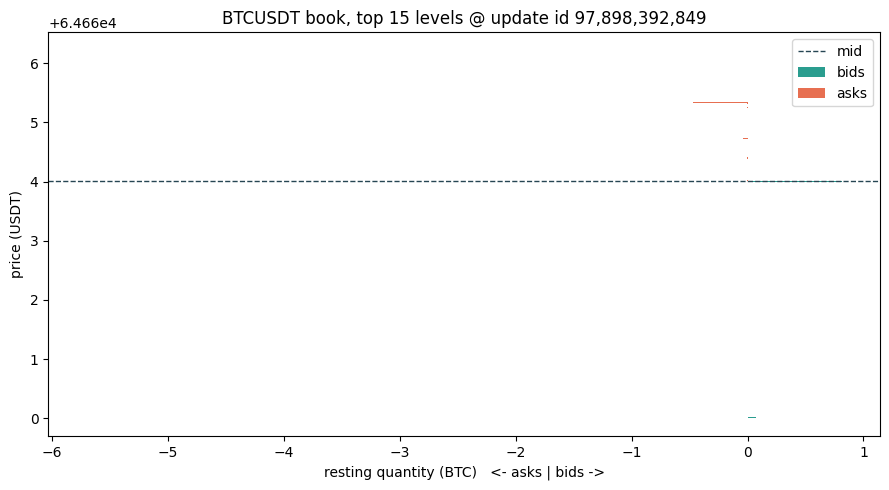

In [6]:
bids, asks = book.top_n(15)
bid_prices = bids[:, 0] / PRICE_SCALE
bid_sizes = bids[:, 1] / QTY_SCALE
ask_prices = asks[:, 0] / PRICE_SCALE
ask_sizes = asks[:, 1] / QTY_SCALE

figure, axis = plt.subplots(figsize=(9, 5))
axis.barh(bid_prices, bid_sizes, height=0.008, color="#2a9d8f", label="bids")
axis.barh(ask_prices, -ask_sizes, height=0.008, color="#e76f51", label="asks")
axis.axhline(book.mid_price(), color="#264653", linestyle="--", linewidth=1, label="mid")
axis.set_xlabel("resting quantity (BTC)   <- asks | bids ->")
axis.set_ylabel("price (USDT)")
axis.set_title(f"BTCUSDT book, top 15 levels @ update id {book.last_update_id:,}")
axis.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Reading the ladder

The touch is thin and the depth is lumpy — a few levels hold most of the
resting size, with gaps between them. That lumpiness is signal, not noise:
the imbalance between the green and red mass near the mid is the single most
predictive cheap feature in microstructure, and it is the first thing
`ml/features.py` will compute in Stage 3.

Also note the vertical scale. Fifteen levels a side spans only a few cents.
Almost all the action is within a hair of the mid.

## 7. The mid over the replay

We recorded the mid after every applied diff. Plotting it shows what ~90
seconds of BTCUSDT actually looks like at this resolution.

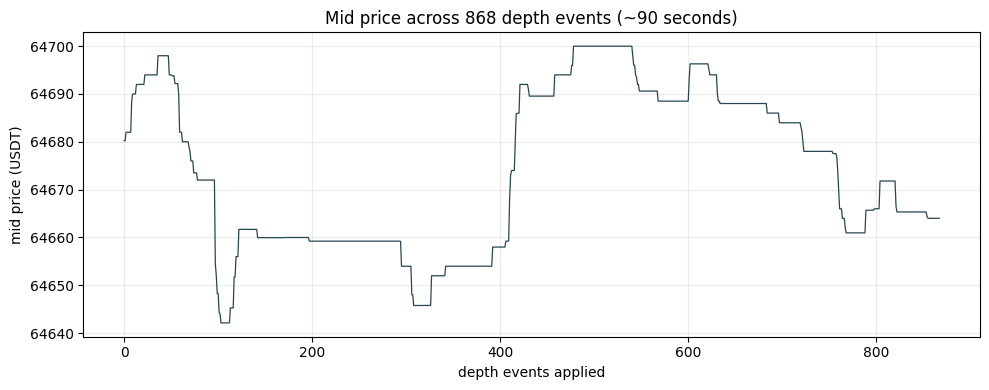

range : 64,642.14 -> 64,700.00
move  : 57.85 USDT (8.9 bps)


In [7]:
figure, axis = plt.subplots(figsize=(10, 4))
axis.plot(mid_history, linewidth=0.9, color="#264653")
axis.set_xlabel("depth events applied")
axis.set_ylabel("mid price (USDT)")
axis.set_title(f"Mid price across {len(mid_history)} depth events (~90 seconds)")
axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"range : {min(mid_history):,.2f} -> {max(mid_history):,.2f}")
print(f"move  : {max(mid_history) - min(mid_history):,.2f} USDT "
      f"({(max(mid_history) - min(mid_history)) / min(mid_history) * 1e4:.1f} bps)")

### What that tells us about the problem

The mid wanders about 58 USDT — roughly 9 basis points — over 90 seconds, in
small steps with no obvious trend. Compare that to the one-cent spread: the
*typical single-event move* is on the order of the spread itself.

That comparison is the entire difficulty of this project stated in one
sentence. Predicting the direction of the next tick is easy and worthless,
because the move is smaller than the cost of capturing it. Stage 3's labels
must therefore be defined over a horizon long enough that the move can exceed
costs, which is why `ml/labels.py` uses a cost-aware deadband instead of the
sign of the next change.

## 8. Breaking it on purpose

Everything above assumed we saw every message. Now suppose we did not — a
dropped frame, a reconnect, a slow consumer. What should happen?

The tempting answer is "carry on, it is only one message". That answer is
wrong, and understanding why is the most important thing in this notebook.

A diff only mentions levels that *changed*. If we miss one, we do not know
which levels it named. Every level in the book is now possibly stale and we
cannot tell which — and a book that is wrong at one unknown price still
produces perfectly smooth, plausible features. The corruption is undetectable
downstream and silently poisons the training data.

So `apply_diff` raises. Let us watch it.

In [8]:
gap_book = OrderBook("BTCUSDT")
gap_book.apply_snapshot(snapshot)

depth_events = [
    json.loads(record["raw"])["data"]
    for record in records[sync_index + 1:sync_index + 400]
    if record["source"] == "websocket" and json.loads(record["raw"])["data"].get("e") == "depthUpdate"
]

for event in depth_events[:5]:
    gap_book.apply_diff(event)
print(f"applied 5 events cleanly, local update id = {gap_book.last_update_id:,}")

try:
    gap_book.apply_diff(depth_events[7])   # deliberately skip events 5 and 6
except SequenceGapError as error:
    print(f"\nraised: {error}")
    print(f"\nbook left untouched at update id {gap_book.last_update_id:,} "
          f"({gap_book.depth()[0]} bids / {gap_book.depth()[1]} asks)")

applied 5 events cleanly, local update id = 97,898,281,651

raised: sequence gap: expected an event starting at U=97898281652, got U=97898282289 u=97898282362 (637 update ids missed)

book left untouched at update id 97,898,281,651 (995 bids / 990 asks)


### A loud failure, and an intact book

Two properties, both deliberate.

**The error is quantitative.** It reports how many update ids were missed, so
an incident log distinguishes one dropped frame from a socket that was dead
for a minute. `SequenceGapError` carries `expected_first_id`,
`event_first_id`, and `missed_updates` as attributes for exactly this.

**The book is unchanged.** The sequence check runs *before* any level is
touched, so a caller that catches the error is not holding a half-updated
book. In `capture.py` the caller does not try to repair it anyway — it tears
the session down and resyncs from a fresh snapshot, and increments a counter.
Losing a second of data is cheap. Not knowing which second is not.

## 9. Proving the book is right

Everything so far shows the book is *self-consistent*. That is not the same as
*correct*: a reconstruction with a systematic bug can satisfy every invariant
while drifting steadily away from what the exchange actually holds.

The only real proof is to ask the exchange. The daemon does this every 60
seconds — fetches a fresh snapshot, compares the top 10 levels, logs
PASS/FAIL. And because it archives those snapshots, we can re-run the same
comparison offline, right here, with no network.

In [9]:
crosscheck_index = next(i for i, r in enumerate(records) if r["source"] == "rest_depth_crosscheck")
crosscheck = json.loads(records[crosscheck_index]["raw"])

replay = OrderBook("BTCUSDT")
replay.apply_snapshot(snapshot)
for record in records[sync_index + 1:crosscheck_index]:
    if record["source"] != "websocket":
        continue
    payload = json.loads(record["raw"])["data"]
    if payload.get("e") == "depthUpdate":
        replay.apply_diff(payload)

reference = OrderBook("BTCUSDT")
reference.apply_snapshot(crosscheck)

local_bids, local_asks = replay.top_n(10)
remote_bids, remote_asks = reference.top_n(10)
print(f"our book id {replay.last_update_id:,} vs snapshot id {reference.last_update_id:,} "
      f"(ahead by {replay.last_update_id - reference.last_update_id})")
print(f"bid prices matching : {int((local_bids[:, 0] == remote_bids[:, 0]).sum())}/10")
print(f"ask prices matching : {int((local_asks[:, 0] == remote_asks[:, 0]).sum())}/10")
print(f"full rows matching  : {int((local_bids == remote_bids).all(axis=1).sum())}/10 bids, "
      f"{int((local_asks == remote_asks).all(axis=1).sum())}/10 asks")

our book id 97,898,364,162 vs snapshot id 97,898,364,069 (ahead by 93)
bid prices matching : 9/10
ask prices matching : 5/10
full rows matching  : 6/10 bids, 3/10 asks


### 11 rows differ. Is the book broken?

No — and being able to explain why is the point of this section.

Our replay is **93 update ids ahead** of the snapshot. The REST request took
time to travel, and the book kept moving while it was in flight, so the two
describe *different instants*. Comparing them is comparing a photo taken now
with one taken a moment ago. The price levels largely agree (9/10 bids); it
is mostly the resting quantities that have moved, which is exactly what you
would expect from time passing rather than from corruption.

This is why `capture.py` classifies a mismatch as **SKEW** rather than FAIL,
and only escalates to FAIL after three consecutive mismatches. Round-trip
skew resolves itself; real corruption does not. An alarm that cries wolf on
every busy minute would be worse than no alarm at all.

And a nice confirmation that the offline path is faithful: the live daemon
logged `cross-check SKEW levels_differing=11` for this exact snapshot. Our
replay produces 4 + 7 = 11. The tape reproduces the daemon exactly.

The genuinely authoritative case is when the ids happen to coincide — when
`local_id == snapshot_id`, the two describe the same instant and *must* match
exactly. This 90-second sample only contains one cross-check, and it is a
skewed one; in a longer run of the same daemon the ids coincided on two
occasions and both logged `PASS` with zero differing levels.

## 10. One more entry point, added in Stage 2

`OrderBook` grew a second way to mutate the book when the binary tape format
arrived: `apply_level_update(is_bid, price, quantity)`. It sets or deletes a
single level and performs **no sequence checking at all**.

That sounds like a hole in the safety property this whole notebook is about,
so it is worth being precise about why it is not.

A binary tape is written by `capture.py` *after* `apply_diff` has already
accepted an event — the gap check ran, and a gap forced a resync before
anything reached the tape. The tape therefore contains validated data by
construction, and it does not store the exchange update ids, because they
already did their job. Re-checking sequence numbers during replay would mean
checking a property of a file we wrote ourselves.

The two entry points are deliberately named so their use is obvious in a code
review: live feed data goes through `apply_diff`, and only a tape goes through
`apply_level_update`. Routing live data to the latter would silently disable
gap detection, which is the single most valuable safety property in
`data_engine`.

In [10]:
demo = OrderBook("BTCUSDT")
demo.apply_snapshot(snapshot)
touch = demo.best_bid()

# The two things a depth diff ever does to a level: resize it, or remove it.
demo.apply_level_update(is_bid=True, price=touch, quantity=25_000_000)
resized_qty = demo.bids[touch]
demo.apply_level_update(is_bid=True, price=touch, quantity=0)
demo.assert_valid()

print(f"touch price      : {touch / PRICE_SCALE:,.2f}")
print(f"qty after resize : {resized_qty / QTY_SCALE:.4f} BTC")
print(f"touch still held : {touch in demo.bids}   (quantity 0 removed it)")
print(f"best bid now     : {demo.best_bid() / PRICE_SCALE:,.2f}   (the next level down)")
print(f"last_update_id   : {demo.last_update_id:,}   (untouched - no sequence tracking here)")

touch price      : 64,680.23
qty after resize : 0.2500 BTC
touch still held : False   (quantity 0 removed it)
best bid now     : 64,680.22   (the next level down)
last_update_id   : 97,898,281,344   (untouched - no sequence tracking here)


### Same level semantics, no sequence machinery

The level operations are identical to what `apply_diff` does internally —
quantity zero deletes, anything else sets — and `assert_valid` still passes.
Deleting the touch simply promotes the next level down to best bid, which is
exactly what happens in the market when the front of the queue is consumed.
What is missing is the `U`/`u` bookkeeping: `last_update_id` is untouched.

(Note the book here is one tick wide, so there is no price *between* the best
bid and the best ask to insert a new level at. Resizing and deleting are the
operations that matter at the touch.)

That last detail matters for replay: a book seeded from a tape keeps
`last_update_id` at its uninitialised sentinel, so if anyone accidentally
feeds it a live diff, `apply_diff` raises immediately rather than inventing a
sequence check against a number that means nothing. The safety property
survives by making the unsafe combination fail loudly instead of quietly.

Notebook 02 picks the story up from here: what those level records look like
on disk, and why they are 40 bytes each.

## Interview checkpoint

**1. Why store prices as scaled integers instead of floats?**
Binary floating point cannot represent most decimal ticks exactly, so the same
price level arriving in two messages can hash to two different float keys —
the book grows a phantom duplicate, and the `quantity = 0` delete only removes
one of them. We store `round(price * 10^8)` as an `int`, which is exact on the
tick grid, exactly comparable, and maps directly onto the fixed-width binary
record in Stage 2. Cell 3 above demonstrates the failure concretely: `0.29`
truncates to `28999999` through a float.

**2. Why raise on a sequence gap instead of refetching a snapshot and
patching the hole?**
Because a diff only names the levels that changed, a missed event leaves us
unable to say *which* levels are now stale — the whole book is suspect, and a
book that is wrong at one unknown price still produces smooth, plausible
features that silently poison training data. Raising converts an invisible
data-quality problem into a loud, countable event: `capture.py` tears the
session down, resyncs from a fresh snapshot, and increments a resync counter
we can watch. Losing a second of data is cheap; not knowing which second is not.

**3. How does the sync algorithm avoid both missing and double-applying a diff?**
The snapshot is a complete state at update id `L` and the diff stream is a
contiguous run of id ranges, so the two failure modes are precisely a hole
before `L` and a replay of history already inside `L`. Step 4 (refetch if
`lastUpdateId < U` of the first buffered event) rules out the snapshot being
older than our buffer, killing the hole; step 5 (discard events with `u <= L`)
rules out replaying anything the snapshot already contains, killing the
double-apply. What survives both filters is exactly the events overlapping or
immediately following `L`, and `apply_diff`'s contiguity check enforces it
from there on.

**4. Your cross-check reported 11 differing levels. Is your book wrong?**
No — the replay was 93 update ids ahead of the snapshot, so the two describe
different instants; the price levels largely agree and it is the quantities
that moved, which is the signature of elapsed time rather than corruption.
The daemon therefore classifies an isolated mismatch as SKEW and only calls
FAIL after three consecutive mismatches, because round-trip skew resolves
itself while real corruption does not. The authoritative case is when the
update ids coincide, and on the two occasions that happened during capture the
daemon logged PASS with zero differing levels.

**5. Why archive raw frames rather than the reconstructed book?**
Storing reconstructed snapshots would bake today's reconstruction logic into
the archive permanently — any bug in the sequencing rules would corrupt data
we could never recover, and Stage 2's binary format would have nothing
independent to validate against. Raw frames are ground truth: we can re-derive
everything, diff a new parser against an old one, and replay history after
fixing a bug. The cost is disk, which is the cheapest resource in this system;
the tape also carries its own REST snapshots so it can be replayed with no
network at all.